# Evaluation
Evaluate a trained model and save confusion matrix to outputs.

Accuracy: 0.5
Precision/Recall/F1: {'precision': 0.5, 'recall': 0.25, 'f1': 0.3333333333333333}


IndexError: list index out of range

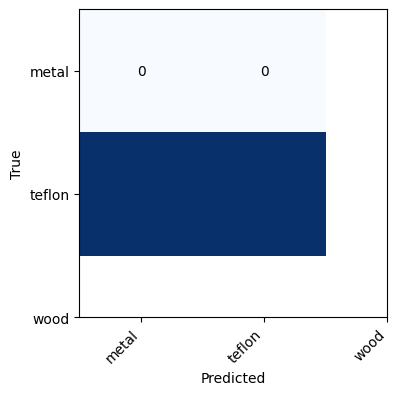

In [5]:
from pathlib import Path
import sys
import torch
from torch.utils.data import DataLoader, random_split

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT))

from src.config import METADATA_CSV
from src.data.metadata import load_metadata, filter_by_set, material_label_map
from src.data.dataset import TWITorchDataset
from src.models.cnn1d import CNN1D
from src.evaluation.metrics import accuracy, macro_precision_recall_f1
from src.evaluation.confusion_matrix import confusion_matrix, plot_confusion_matrix
from src.processing.preprocess import preprocess_signal

base_folder = ROOT / "data" / "36"
mat_key = "dataMeasured1"

metadata = load_metadata(METADATA_CSV)
metadata = filter_by_set(metadata, "single")
metadata = metadata[metadata["material"].notna()]
label_map = material_label_map(metadata)

file_paths = []
labels = []
for _, row in metadata.iterrows():
    mat_path = base_folder / str(int(row["folder_id"])) / "data.mat"
    if mat_path.exists():
        file_paths.append(mat_path)
        labels.append(label_map[row["material"]])

dataset = TWITorchDataset(file_paths, labels, mat_key=mat_key, transform=preprocess_signal)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
_, test_set = random_split(dataset, [train_size, test_size])

test_loader = DataLoader(test_set, batch_size=8, shuffle=False)

sample_x, _ = dataset[0]
model = CNN1D(in_channels=int(sample_x.shape[0]), num_classes=len(label_map))
model_path = ROOT / "outputs" / "models" / "best_model_nb.pt"
model.load_state_dict(torch.load(model_path, map_location="cpu"))
model.eval()

y_true = []
y_pred = []
with torch.no_grad():
    for x, y in test_loader:
        logits = model(x)
        preds = torch.argmax(logits, dim=1).tolist()
        y_true.extend(y.tolist())
        y_pred.extend(preds)

acc = accuracy(y_true, y_pred)
prf = macro_precision_recall_f1(y_true, y_pred)
print("Accuracy:", acc)
print("Precision/Recall/F1:", prf)

label_names = {v: k for k, v in label_map.items()}
labels_sorted = [label_names[i] for i in sorted(label_names.keys())]
_, cm = confusion_matrix(y_true, y_pred)

out = ROOT / "outputs" / "figures" / "confusion_matrix_nb.png"
plot_confusion_matrix(labels_sorted, cm, out)
print("Saved confusion matrix to", out)